In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import linregress
from visualizations import lineplots_4x4
from processing import filter_region

# load prediction arrays, create array objects

In [10]:
def load_arrs(arr_type: str, folder_path):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [11]:
folder_path_stochbin = 'predictions/8-27-2025/'
folder_path_sigma10 = 'predictions/sigma10'

In [12]:
stochbin_sum = load_arrs('sum', folder_path_stochbin)
stochbin_mean = load_arrs('mean', folder_path_stochbin)
stochbin_var = load_arrs('var', folder_path_stochbin)
stochbin_label = load_arrs('label', folder_path_stochbin)

In [13]:
# load for those in sigma10
"""
later need to make this generalize to different systems
"""
sigma10_sum = np.load(folder_path_sigma10 + "/sum_sigma10.npy")
sigma10_mean = np.load(folder_path_sigma10 + "/mean_sigma10.npy")
sigma10_var = np.load(folder_path_sigma10 + "/var_sigma10.npy")
sigma10_label = np.load(folder_path_sigma10 + "/labels_sigma10.npy")

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [14]:
v1mean_stochbin = filter_region(1, stochbin_label, stochbin_mean)
v1var_stochbin = filter_region(1, stochbin_label, stochbin_var)

"""
NOTE USING LABELS FROM V1MEAN TO FILTER HERE, ASSUMING THIS IS FINE SINCE IT IS THE SAME NEURONS 
"""

v1mean_sigma10 = filter_region(1, stochbin_label, sigma10_mean)
v1var_sigma10 = filter_region(1, stochbin_label, sigma10_var)

In [18]:
# delete 9 grey images

v1mean_sigma10 = v1mean_sigma10[9:, ...]
v1var_sigma10 = v1var_sigma10[9:,...]
v1mean_stochbin = v1mean_stochbin[9:,...]
v1var_stochbin = v1var_stochbin[9:,...]

# get indices to sort

In [23]:
# run this when wanting to use array with removed values
med_arr = np.nanmedian(mean_v1_removed, axis = 0)
med_arr.shape

NameError: name 'mean_v1_removed' is not defined

In [19]:
# run this when wanting to use array WITHOUT removed values
stochbin_med = np.nanmedian(v1mean_stochbin, axis = 0)
sigma10_med = np.nanmedian(v1mean_sigma10, axis = 0)

In [20]:
stochbin_sort_indices = np.argsort(stochbin_med)[::-1]
sigma10_sort_indices = np.argsort(sigma10_med)[::-1]

In [21]:
# use this for when we remove above x rate
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

NameError: name 'mean_v1_removed' is not defined

In [35]:
# use this OTHERWISE
stochbin_meanv1 = v1mean_stochbin[..., stochbin_sort_indices]
stochbin_varv1 = v1var_stochbin[..., stochbin_sort_indices]

sigma10_meanv1 = v1mean_sigma10[..., sigma10_sort_indices]
sigma10_varv1 = v1var_sigma10[..., sigma10_sort_indices]

# ax**b function in log log space
*scatter plot*

In [28]:
def smooth_func(a, x, b): # used for regression in lineplots_4x4

    return a * (x ** b)

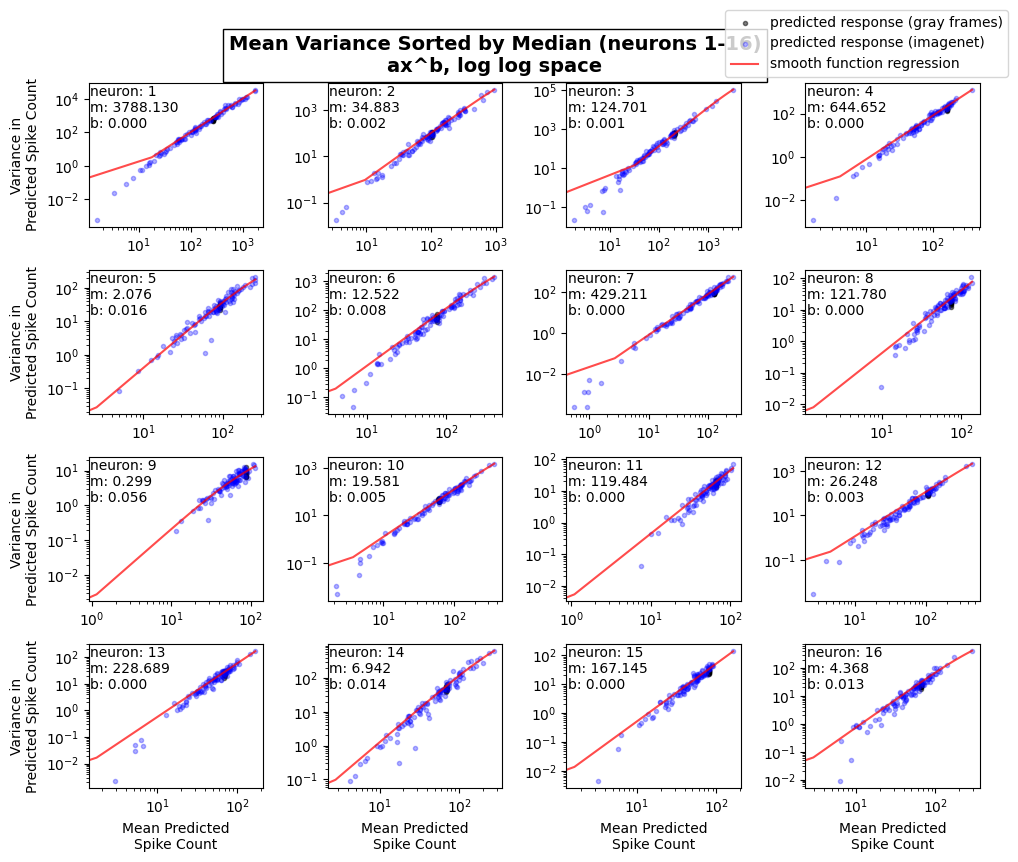

In [ ]:
lineplots_4x4("Mean Variance Sorted by Median (neurons 1-16)\nax^b, log log space", stochbin_meanv1, stochbin_varv1, neurons = [i for i in range(16)], savefig = False, logspace = True)

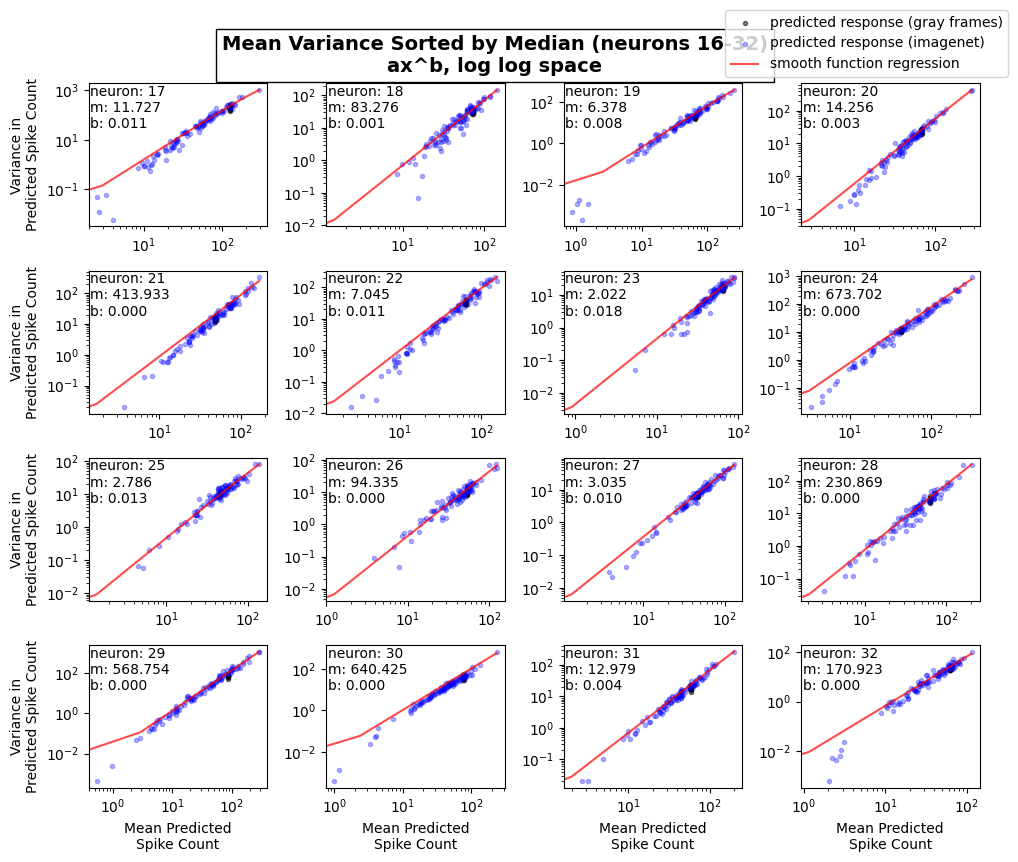

In [ ]:
lineplots_4x4("Mean Variance Sorted by Median (neurons 16-32)\nax^b, log log space", mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16, 32)], savefig = False, logspace = True)

# regression
log(y) = a + blog(x)

In [51]:
mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title = "Mean Variance Scatter Plot\nStochastic Bernoulli (neurons 1-16)"

In [ ]:
def scatter_plots(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], loglog_space = False, savefig = False):
    """
    Scatter plot of mean and variance spike counts with option to plot in log log space. If figure saved will save to same directory as script.
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        x = mean_masked[..., neuron]
        y = var_masked[..., neuron]
        logx = np.log(x)
        logy = np.log(y)

        b, a, r_value, p_value, std_err = linregress(logx, logy)
        r_squared = r_value**2

        x_fit = np.linspace(x.min(), x.max(), 101) 
        y_fit = np.exp(a) * x_fit**b
        max_exp = np.max(x_fit) 
        """
        should identity line be drawn same way for loglog space versus spike count?
        """
        if loglog_space:
            ax.loglog(x, y, '.', label = 'original mean and var points')
            ax.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
            ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
        else:
            ax.scatter(x, y, marker = '.', label = 'original mean and var points')
            ax.plot(x_fit, y_fit, color = 'r', label = 'regression')
            ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')


        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nb: {b:.3f}\na: {a:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
            transform = ax.transAxes)

        if i == 3: ax.set_xlabel("mean spike count")
        if j == 0: ax.set_ylabel("variance in spike count")
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))

    if savefig:
        import time
        current_time = time.localtime()
        formatted_time = time.strftime("%Y-%m-%d", current_time)
        plt.savefig(f"scatterplot({formatted_time}).pdf")
    else:
        plt.tight_layout()
        plt.show()
    

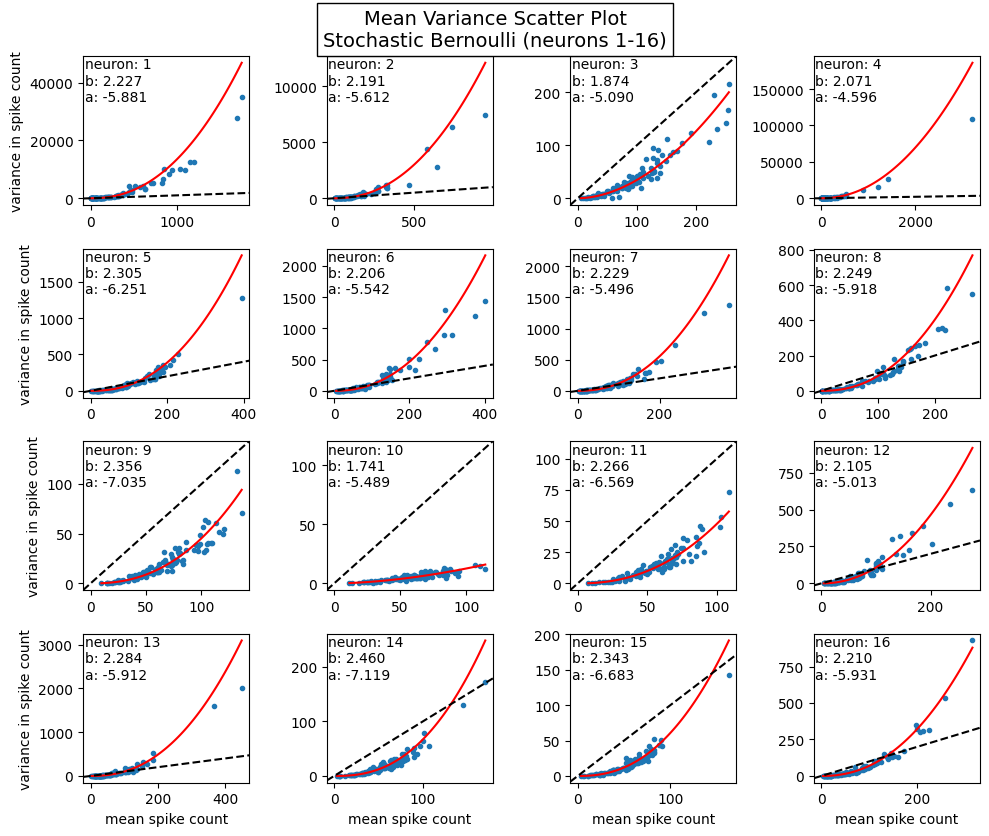

In [61]:
scatter_plots(main_title, stochbin_meanv1, stochbin_varv1, loglog_space = False)

Note our points fall lower than identity line in real neurons, intercept is lower as well.

In [ ]:
mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
main_title = "Mean Variance Scatter Plot\nDynamic Gaussian Noise with Sigma=10 (neurons 1-16)"

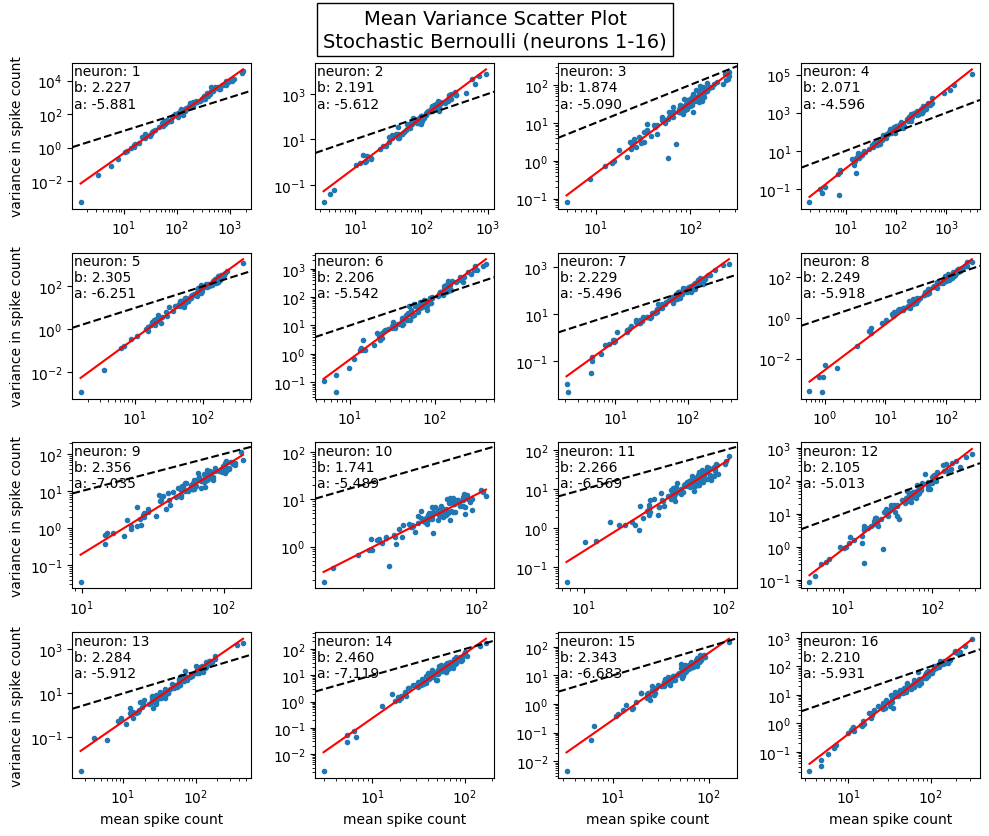

In [63]:
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
neurons = [i for i in range(16)]
for id, neuron in enumerate(neurons):
    i, j = divmod(id, 4)
    ax = axes[i, j]
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy)
    r_squared = r_value**2

    x_fit = np.linspace(x.min(), x.max(), 101)
    y_fit = np.exp(a) * x_fit**b

    ax.loglog(x, y, '.', label = 'original mean and var points')
    ax.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
    max_exp = np.max(x_fit)
    ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
    ax.text(0.01, 0.99, f'neuron: {neuron+1}\nb: {b:.3f}\na: {a:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
        transform = ax.transAxes)

    if i == 3: ax.set_xlabel("mean spike count")
    if j == 0: ax.set_ylabel("variance in spike count")
fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()

# a,b, r^2 versus median

In [28]:
mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title ="variance = a*mean^b\nStochastic Bernoulli Noise with Sigma-10 (neurons 1-16)"

# pre allocate statistics 
stochbin_medians = []
stochbin_alist = []
stochbin_blist = []
stochbin_rsqlist = []

neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    stochbin_medians.append(med)
    stochbin_alist.append(a)
    stochbin_blist.append(b)
    stochbin_rsqlist.append(r_squared)
stochbin_alist = np.exp(stochbin_alist)


#---now do for sigma=10 dynamic gaussian noise---
sigma10_medians = []
sigma10_alist = []
sigma10_blist = []
sigma10_rsqlist = []

mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    sigma10_medians.append(med)
    sigma10_alist.append(a)
    sigma10_blist.append(b)
    sigma10_rsqlist.append(r_squared)
sigma10_alist = np.exp(sigma10_alist)

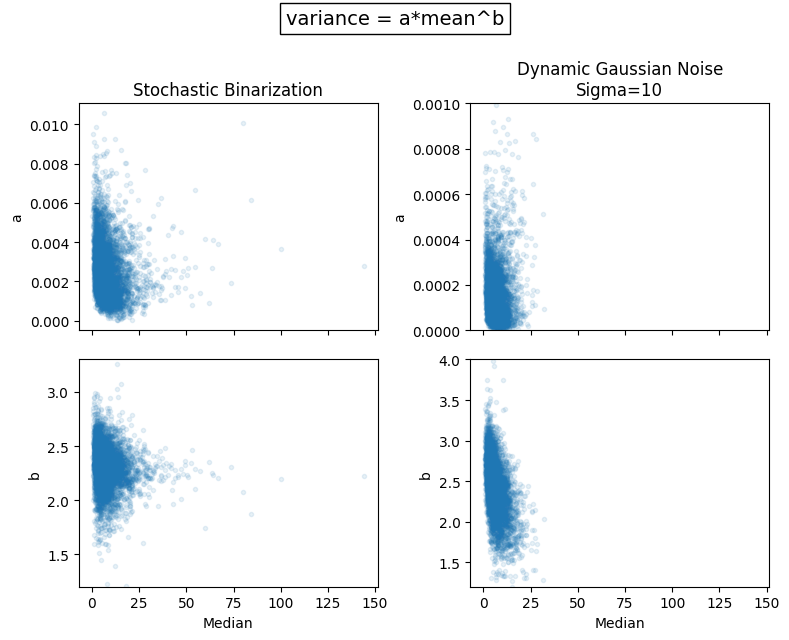

In [30]:
"""
do 2 sets of plots
1) 2x2 for equation parameters (a and b) by different type of noise 
2) r_squared for each (just 2 scatter plots side by side)
"""

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=False)

axes[0,0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0,0].set_ylabel("a")
#axes[0,0].set_ylim(0, 0.001)
axes[0,0].set_title("Stochastic Binarization")

axes[1,0].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1,0].set_ylabel("b")
axes[1,0].set_ylim(1.2, 3.3)
axes[1,0].set_xlabel("Median")

axes[0,1].scatter(sigma10_medians, sigma10_alist, marker = ".", alpha = 0.1)
axes[0,1].set_ylabel("a")
axes[0,1].set_ylim(0, 0.001) 
axes[0,1].set_title("Dynamic Gaussian Noise\nSigma=10")

axes[1,1].scatter(sigma10_medians, sigma10_blist, marker = ".", alpha = 0.1)
axes[1,1].set_ylabel("b")
axes[1,1].set_ylim(1.2, 4)
axes[1,1].set_xlabel("Median")


fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

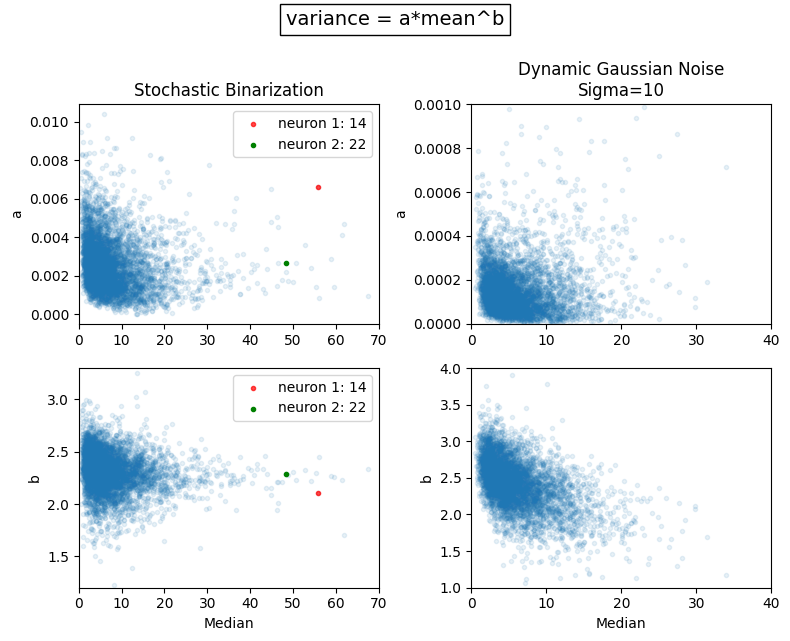

median: 55.8980; b: 2.1054; a: 0.0066
median: 48.2663; b: 2.2894; a: 0.0027


In [106]:
"""
single out neuron i and show a against b
"""
neuron1 = 13
neuron2 = 21

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False)

axes[0,0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0,0].scatter(stochbin_medians[neuron1], stochbin_alist[neuron1], marker = ".", 
                  color = "red", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[0,0].scatter(stochbin_medians[neuron2], stochbin_alist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[0,0].set_ylabel("a")
axes[0,0].set_title("Stochastic Binarization")
axes[0,0].legend()
axes[0,0].set_xlim(0, 70)

axes[1,0].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1,0].scatter(stochbin_medians[neuron1], stochbin_blist[neuron1], marker = ".", 
                  color = "r", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[1,0].scatter(stochbin_medians[neuron2], stochbin_blist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[1,0].set_ylabel("b")
axes[1,0].set_ylim(1.2, 3.3)
axes[1,0].set_xlabel("Median")
axes[1,0].legend()
axes[1,0].set_xlim(0, 70)

axes[0,1].scatter(sigma10_medians, sigma10_alist, marker = ".", alpha = 0.1)
axes[0,1].set_ylabel("a")
axes[0,1].set_ylim(0, 0.001) 
axes[0,1].set_title("Dynamic Gaussian Noise\nSigma=10")
axes[0,1].set_xlim(0, 40)

axes[1,1].scatter(sigma10_medians, sigma10_blist, marker = ".", alpha = 0.1)
axes[1,1].set_ylabel("b")
axes[1,1].set_ylim(1, 4)
axes[1,1].set_xlabel("Median")
axes[1,1].set_xlim(0, 40)

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

print(f"median: {stochbin_medians[neuron1]:.4f}; b: {stochbin_blist[neuron1]:.4f}; a: {stochbin_alist[neuron1]:.4f}")
print(f"median: {stochbin_medians[neuron2]:.4f}; b: {stochbin_blist[neuron2]:.4f}; a: {stochbin_alist[neuron2]:.4f}")

a1 = stochbin_alist[neuron1]
a2 = stochbin_alist[neuron2]

In [87]:
possible_neurons = np.where((np.array(stochbin_alist) > 0.006) & (np.array(stochbin_medians) > 45))

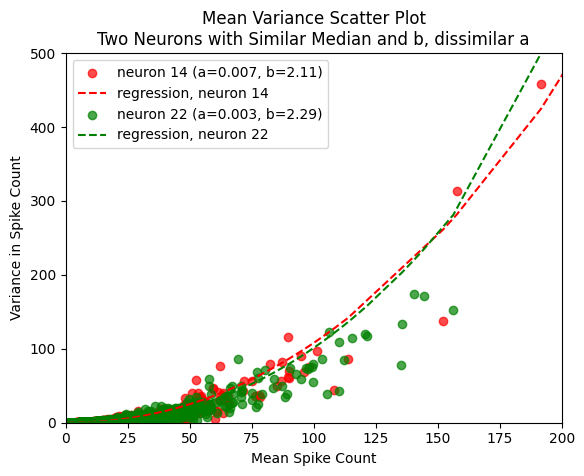

In [99]:
plt.scatter(stochbin_meanv1[neuron1], stochbin_varv1[neuron1], color = "r", 
            label = f"neuron {neuron1+1} (a={stochbin_alist[neuron1]:.3f}, b={stochbin_blist[neuron1]:.2f})", alpha = 0.7)
x = np.sort(stochbin_meanv1[neuron1])
y = stochbin_alist[neuron1] * x**stochbin_blist[neuron1]
plt.plot(x, y, label = f"regression, neuron {neuron1+1}", linestyle = "--", color = "r")

plt.scatter(stochbin_meanv1[neuron2], stochbin_varv1[neuron2], color = "g", 
            label = f"neuron {neuron2+1} (a={stochbin_alist[neuron2]:.3f}, b={stochbin_blist[neuron2]:.2f})", alpha = 0.7)
x = np.sort(stochbin_meanv1[neuron2])
y = stochbin_alist[neuron2] * x**stochbin_blist[neuron2]
plt.plot(x, y, label = f"regression, neuron {neuron2+1}", linestyle = "--", color = "g")

plt.legend()
plt.xlabel("Mean Spike Count")
plt.ylabel("Variance in Spike Count")
plt.title("Mean Variance Scatter Plot\nTwo Neurons with Similar Median and b, dissimilar a")
plt.ylim(0, 500)
plt.xlim(0, 200)
plt.show()

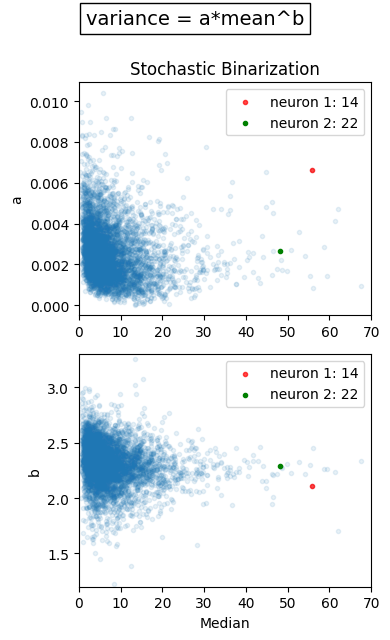

median: 55.8980; b: 2.1054; a: 0.0066
median: 48.2663; b: 2.2894; a: 0.0027


In [102]:
"""
single out neuron i and show a against b
"""
neuron1 = 13
neuron2 = 21

fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharey=False)

axes[0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0].scatter(stochbin_medians[neuron1], stochbin_alist[neuron1], marker = ".", 
                  color = "red", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[0].scatter(stochbin_medians[neuron2], stochbin_alist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[0].set_ylabel("a")
axes[0].set_title("Stochastic Binarization")
axes[0].legend()
axes[0].set_xlim(0, 70)

axes[1].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1].scatter(stochbin_medians[neuron1], stochbin_blist[neuron1], marker = ".", 
                  color = "r", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[1].scatter(stochbin_medians[neuron2], stochbin_blist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[1].set_ylabel("b")
axes[1].set_ylim(1.2, 3.3)
axes[1].set_xlabel("Median")
axes[1].legend()
axes[1].set_xlim(0, 70)

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

print(f"median: {stochbin_medians[neuron1]:.4f}; b: {stochbin_blist[neuron1]:.4f}; a: {stochbin_alist[neuron1]:.4f}")
print(f"median: {stochbin_medians[neuron2]:.4f}; b: {stochbin_blist[neuron2]:.4f}; a: {stochbin_alist[neuron2]:.4f}")

a1 = stochbin_alist[neuron1]
a2 = stochbin_alist[neuron2]

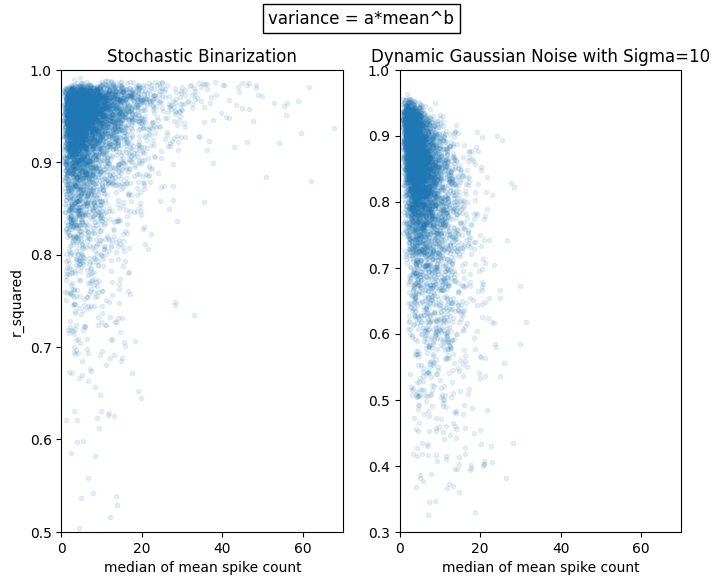

In [54]:
plt.figure(figsize = (8, 6))
plt.subplot(121)
plt.ylabel("r_squared")
plt.scatter(stochbin_medians, stochbin_rsqlist, marker = ".", alpha = 0.1)
plt.ylim(0.5, 1)
plt.xlim(0, 70)
plt.xlabel("median of mean spike count")
plt.title("Stochastic Binarization")

plt.subplot(122)
plt.title("Dynamic Gaussian Noise with Sigma=10")
plt.scatter(sigma10_medians, sigma10_rsqlist, marker = ".", alpha = 0.1)
plt.ylim(0.3, 1)
plt.xlim(0, 70)
plt.xlabel("median of mean spike count")

plt.suptitle("variance = a*mean^b", bbox=dict(facecolor='white'))
plt.show()

play around with moving averages

In [ ]:
 window_size = 10 # what window size to use, 10 for now?
    weights = np.ones(window_size) / window_size
    sma_numpy = np.convolve(data, weights, mode='valid')

IndentationError: unexpected indent (202640303.py, line 2)

# histograms a, b, r^2

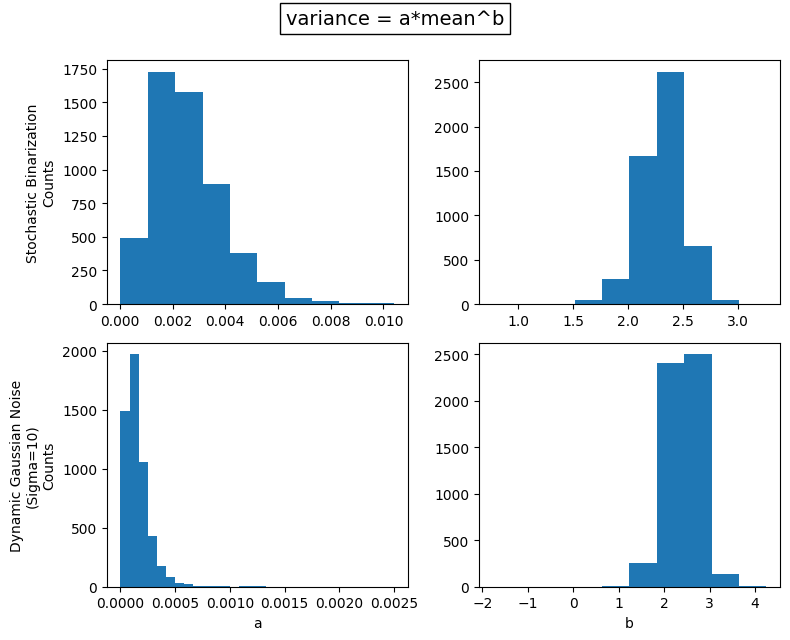

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].hist(stochbin_alist)
axes[0,0].set_ylabel("Stochastic Binarization\nCounts")

axes[0,1].hist(stochbin_blist)

axes[1,0].hist(sigma10_alist, range = (0, 0.0025), bins = 30)
axes[1,0].set_xlabel("a")
axes[1,0].set_ylabel("Dynamic Gaussian Noise\n(Sigma=10)\nCounts")

axes[1,1].hist(sigma10_blist)
axes[1,1].set_xlabel("b")

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()

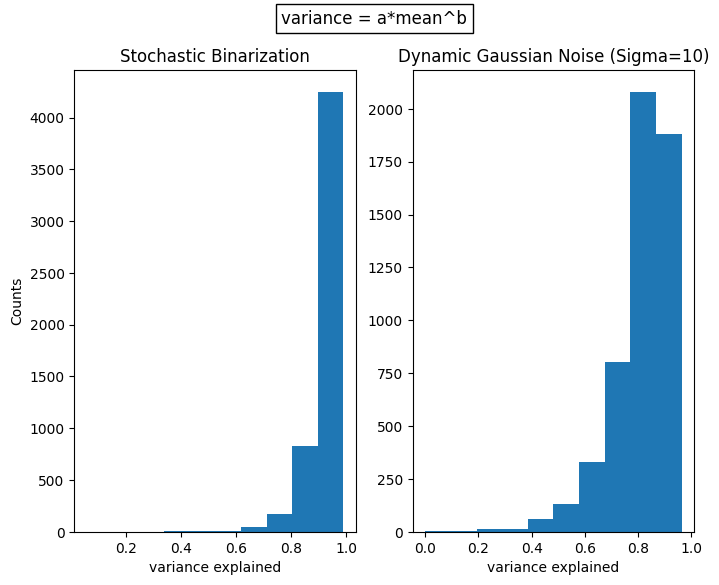

In [32]:
plt.figure(figsize = (8, 6))
plt.subplot(121)
plt.hist(stochbin_rsqlist)
plt.xlabel("variance explained")
plt.ylabel("Counts")
plt.title("Stochastic Binarization")

plt.subplot(122)
plt.title("Dynamic Gaussian Noise (Sigma=10)")
plt.hist(sigma10_rsqlist)
plt.xlabel("variance explained")

plt.suptitle("variance = a*mean^b", bbox=dict(facecolor='white'))
plt.show()

# all neurons mean var scatter

In [66]:
x = stochbin_mean.flatten()
y = stochbin_var.flatten()

logx = np.log(x)
logy = np.log(y)

b, a, r_value, p_value, std_err = linregress(logx, logy)
r_squared = r_value**2

x_fit = np.linspace(x.min(), x.max(), 101)
y_fit = np.exp(a) * x_fit**b
max_exp = max(x_fit)

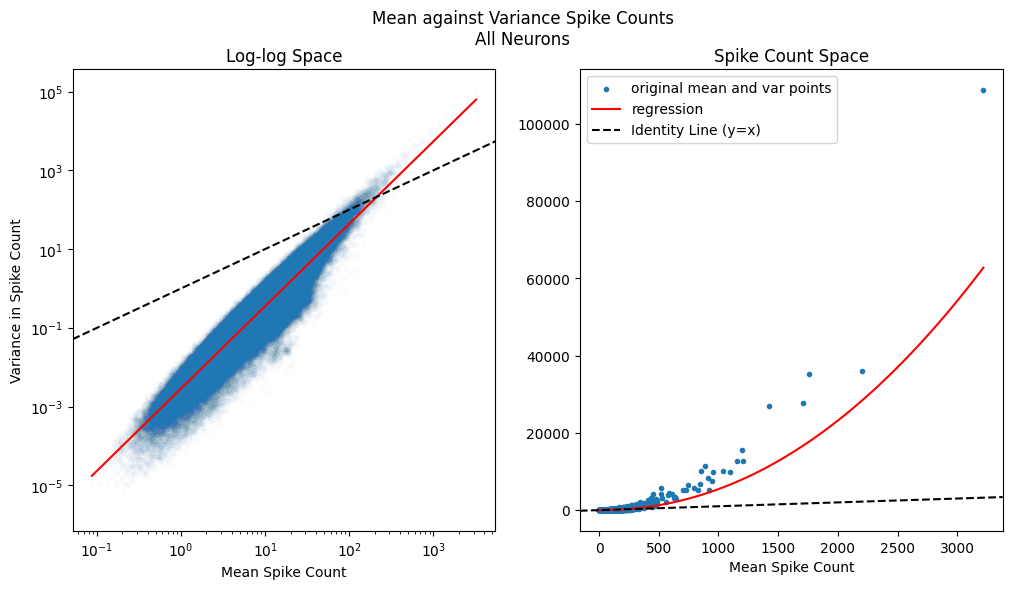

In [83]:
plt.figure(figsize = (12,6))
plt.suptitle("Mean against Variance Spike Counts\nAll Neurons")
plt.subplot(121)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01)
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.title("Log-log Space")
plt.xlabel("Mean Spike Count")
plt.ylabel("Variance in Spike Count")

plt.subplot(122)
plt.scatter(x, y, marker = '.', label = 'original mean and var points')
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.title("Spike Count Space")
plt.xlabel("Mean Spike Count")
plt.legend()

plt.show()